# Chunking Strategies Lab: Podcast Transcript vs PDF Document

> **Updated:** Supports uploading a **local PDF** and a **local audio file**.  
> The audio is transcribed via OpenAI Whisper and saved to `transcriptions/`.  
> Chunking strategies are then applied to whatever texts you load (uploaded or synthetic).


## 0. Setup & Installs

In [6]:
import subprocess, sys
pkgs = ["langchain", "langchain-community", "langchain-text-splitters",
        "PyPDF2", "openai", "matplotlib", "seaborn", "scikit-learn", "python-dotenv"]
subprocess.check_call([sys.executable, "-m", "pip", "install",
                       "--break-system-packages", "--quiet", *pkgs])
print("All packages installed")

All packages installed


## 1. Imports & Configuration

In [27]:
%matplotlib inline

import re, os, pathlib, warnings, textwrap
from dotenv import load_dotenv
warnings.filterwarnings("ignore")

# ── Load environment variables from .env file ────────────────────────────
load_dotenv()

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd

from langchain_text_splitters import CharacterTextSplitter, RecursiveCharacterTextSplitter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import PyPDF2
from openai import OpenAI

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

# ── OpenAI client (reads OPENAI_API_KEY from .env or environment) ────────
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("OPENAI_API_KEY not found. Please set it in .env file or environment.")
client = OpenAI(api_key=api_key)

# ── Output folders ───────────────────────────────────────────────────────
TRANSCRIPTIONS_DIR = pathlib.Path("transcriptions")
TRANSCRIPTIONS_DIR.mkdir(exist_ok=True)

print("Imports OK")
print(f"Transcriptions will be saved to: {TRANSCRIPTIONS_DIR.resolve()}")

Imports OK
Transcriptions will be saved to: /Users/markusvonaschoff/Desktop/ironhack_Bootcamp/Deliverables/Week 2/Lab 5/transcriptions


## 2. Load PDF (upload or use synthetic fallback)

**How to use:**
1. Place your PDF in the same directory as this notebook (or provide a full path).
2. Set `PDF_PATH` to the filename.
3. If left as `None`, a synthetic Trustworthy AI text is used instead.


In [8]:
# ── USER CONFIGURATION ────────────────────────────────────────────────────
PDF_PATH = "ai_hleg_ethics_guidelines_for_trustworthy_ai-en.pdf"          # e.g. "my_document.pdf" — set to None for synthetic fallback
# ─────────────────────────────────────────────────────────────────────────

def extract_pdf_text(path: str) -> str:
    """Extract all text from a PDF file using PyPDF2."""
    text_parts = []
    with open(path, "rb") as f:
        reader = PyPDF2.PdfReader(f)
        print(f"  PDF pages: {len(reader.pages)}")
        for i, page in enumerate(reader.pages):
            page_text = page.extract_text() or ""
            text_parts.append(page_text)
            print(f"  Page {i+1}: {len(page_text)} chars extracted")
    return "\n\n".join(text_parts)

SYNTHETIC_PDF = """Trustworthy AI: Principles and Practice

1. Introduction
Artificial intelligence systems are increasingly deployed in high-stakes domains including healthcare,
criminal justice, finance, and autonomous vehicles. Ensuring their trustworthiness is a societal
imperative. Trustworthy AI encompasses safety, reliability, fairness, transparency, privacy,
accountability, and human oversight.

2. Safety and Reliability
A safe AI system does not cause unintended harm. Reliability means consistent, predictable
performance. Key techniques: formal verification, red-teaming, runtime monitors, staged rollout.
Safety benchmarks such as HellaSwag, TruthfulQA, and BBQ standardise evaluation.

3. Fairness and Non-Discrimination
Fairness definitions (demographic parity, equalised odds, individual fairness) are mathematically
incompatible in general. Bias enters during data collection, feature engineering, training, and
deployment. Mitigation: pre-processing, in-processing, post-processing approaches.

4. Transparency and Explainability
Transparency is openness about how a system works; explainability provides human-understandable
rationales. Methods include LIME, SHAP, attention visualisation, and counterfactual explanations.

5. Privacy and Data Governance
AI models inherit privacy risks from training data. Differential privacy adds calibrated noise
to training updates. Data governance: minimisation, access controls, retention schedules, DPIAs.

6. Human Oversight and Accountability
Oversight mechanisms: human-in-the-loop pipelines, audit logs, third-party audits. Accountability
requires clear responsibility assignment across data providers, developers, integrators, deployers.

7. Governance Frameworks
- NIST AI RMF: Govern, Map, Measure, Manage.
- EU AI Act: risk-tiered obligations (unacceptable / high / limited / minimal).
- ISO/IEC 42001: AI management systems standard.

8. Conclusion
Building trustworthy AI requires collaboration among engineers, ethicists, policymakers,
and affected communities. Technical tools must pair with regulatory oversight.
"""

if PDF_PATH and os.path.exists(PDF_PATH):
    print(f"Extracting text from PDF: {PDF_PATH}")
    pdf_text = extract_pdf_text(PDF_PATH)
    print(f"\nTotal extracted: {len(pdf_text):,} characters")
else:
    if PDF_PATH:
        print(f"File not found: {PDF_PATH!r}  — using synthetic fallback.")
    else:
        print("PDF_PATH not set — using synthetic Trustworthy AI text.")
    pdf_text = SYNTHETIC_PDF

print(f"\nPDF text ready: {len(pdf_text):,} chars | ~{len(pdf_text.split()):,} words")
print("Preview (first 300 chars):")
print(textwrap.fill(pdf_text[:300], width=80))


Extracting text from PDF: ai_hleg_ethics_guidelines_for_trustworthy_ai-en.pdf
  PDF pages: 41
  Page 1: 171 chars extracted
  Page 2: 2424 chars extracted
  Page 3: 521 chars extracted
  Page 4: 4335 chars extracted
  Page 5: 3978 chars extracted
  Page 6: 4768 chars extracted
  Page 7: 4565 chars extracted
  Page 8: 4497 chars extracted
  Page 9: 3117 chars extracted
  Page 10: 82 chars extracted
  Page 11: 4969 chars extracted
  Page 12: 5130 chars extracted
  Page 13: 5076 chars extracted
  Page 14: 4418 chars extracted
  Page 15: 4974 chars extracted
  Page 16: 3277 chars extracted
  Page 17: 2365 chars extracted
  Page 18: 5259 chars extracted
  Page 19: 4882 chars extracted
  Page 20: 4973 chars extracted
  Page 21: 4671 chars extracted
  Page 22: 4112 chars extracted
  Page 23: 4467 chars extracted
  Page 24: 4206 chars extracted
  Page 25: 4137 chars extracted
  Page 26: 4142 chars extracted
  Page 27: 4239 chars extracted
  Page 28: 3486 chars extracted
  Page 29: 3439 chars e

## 3. Load Audio & Transcribe (upload or use synthetic fallback)

**How to use:**
1. Place your audio file (MP3, WAV, M4A, FLAC, OGG, WEBM) next to this notebook.
2. Set `AUDIO_PATH` to the filename.
3. The transcription is saved to `transcriptions/<audio_stem>.txt` and reused on subsequent runs.
4. If `AUDIO_PATH = None`, a synthetic podcast transcript is used instead.

> **Note:** Transcription uses OpenAI Whisper API (`whisper-1`). Ensure `OPENAI_API_KEY` is set.


In [9]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "pydub"])

from pydub import AudioSegment
from pydub.utils import make_chunks

def split_audio_file(input_path: str, output_dir: str = "audio_chunks", chunk_mb: int = 20):
    """
    Split a large audio file into smaller chunks under the Whisper 25 MB limit.
    
    Args:
        input_path: Path to the audio file to split
        output_dir: Directory to save the chunks
        chunk_mb: Target size per chunk in MB (default 20 to leave margin)
    """
    input_path = pathlib.Path(input_path)
    output_dir = pathlib.Path(output_dir)
    output_dir.mkdir(exist_ok=True)
    
    # Load audio file
    print(f"Loading audio: {input_path.name}")
    audio = AudioSegment.from_file(str(input_path))
    
    file_size_mb = input_path.stat().st_size / 1024 / 1024
    audio_duration_sec = len(audio) / 1000  # convert ms to seconds
    
    print(f"  Duration: {audio_duration_sec:.1f} seconds ({file_size_mb:.1f} MB)")
    
    # Estimate chunk duration based on file size and target MB size
    chunk_duration_sec = (chunk_mb * 1024 * 1024) / (input_path.stat().st_size / audio_duration_sec)
    chunk_duration_ms = int(chunk_duration_sec * 1000)
    
    print(f"  Splitting into ~{chunk_duration_sec:.0f}s chunks...")
    
    chunks = make_chunks(audio, chunk_duration_ms)
    
    # Map file extensions to ffmpeg formats
    format_map = {
        ".m4a": "ipod",
        ".mp4": "mp4",
        ".mp3": "mp3",
        ".wav": "wav",
        ".flac": "flac",
        ".ogg": "ogg",
        ".webm": "webm",
    }
    export_format = format_map.get(input_path.suffix.lower(), input_path.suffix[1:])
    
    # Export chunks
    saved_paths = []
    for i, chunk in enumerate(chunks, 1):
        chunk_path = output_dir / f"{input_path.stem}_part{i}{input_path.suffix}"
        chunk.export(str(chunk_path), format=export_format)
        chunk_size_mb = chunk_path.stat().st_size / 1024 / 1024
        saved_paths.append(chunk_path)
        print(f"  [{i}] {chunk_path.name}  ({chunk_size_mb:.1f} MB)")
    
    return saved_paths

print("Audio splitting function ready. It will be called automatically if needed.")

Audio splitting function ready. It will be called automatically if needed.


In [11]:
# ── USER CONFIGURATION ────────────────────────────────────────────────────
import os, pathlib
AUDIO_PATH = "The_Blueprint_For_Trustworthy_AI.m4a"        # e.g. "podcast_episode.mp3" — set to None for synthetic fallback
WHISPER_MODEL = "whisper-1"
# ─────────────────────────────────────────────────────────────────────────


MAX_WHISPER_BYTES = 25 * 1024 * 1024   # Whisper API limit: 25 MB

SUPPORTED_AUDIO = {".mp3",".wav",".m4a",".flac",".ogg",".webm",".mp4"}

def transcribe_audio(audio_path: str) -> str:
    """
    Transcribe an audio file with OpenAI Whisper.
    - If file > 25 MB, automatically splits it into chunks and transcribes the first one.
    - Result is cached in transcriptions/<stem>.txt.
    """
    audio_path = pathlib.Path(audio_path)
    if audio_path.suffix.lower() not in SUPPORTED_AUDIO:
        raise ValueError(f"Unsupported audio format: {audio_path.suffix}. "
                         f"Supported: {SUPPORTED_AUDIO}")

    save_path = TRANSCRIPTIONS_DIR / (audio_path.stem + ".txt")

    # ── Return cached transcription if it exists ─────────────────────────
    if save_path.exists():
        print(f"Cached transcription found: {save_path}")
        return save_path.read_text(encoding="utf-8")

    # ── Check file size ───────────────────────────────────────────────────
    size_bytes = audio_path.stat().st_size
    print(f"Audio file : {audio_path.name}  ({size_bytes/1024/1024:.1f} MB)")
    
    if size_bytes > MAX_WHISPER_BYTES:
        print(f"  File exceeds 25 MB limit. Splitting into chunks...")
        from pydub import AudioSegment
        from pydub.utils import make_chunks
        
        # Load and split audio
        audio = AudioSegment.from_file(str(audio_path))
        audio_duration_sec = len(audio) / 1000
        chunk_mb = 20
        chunk_duration_sec = (chunk_mb * 1024 * 1024) / (size_bytes / audio_duration_sec)
        chunk_duration_ms = int(chunk_duration_sec * 1000)
        chunks_list = list(make_chunks(audio, chunk_duration_ms))
        
        # Map file extensions to ffmpeg formats
        format_map = {
            ".m4a": "ipod", ".mp4": "mp4", ".mp3": "mp3", ".wav": "wav",
            ".flac": "flac", ".ogg": "ogg", ".webm": "webm",
        }
        export_format = format_map.get(audio_path.suffix.lower(), audio_path.suffix[1:])
        
        # Export first chunk
        first_chunk_path = TRANSCRIPTIONS_DIR / f"{audio_path.stem}_chunk1{audio_path.suffix}"
        chunks_list[0].export(str(first_chunk_path), format=export_format)
        chunk_size_mb = first_chunk_path.stat().st_size / 1024 / 1024
        print(f"  Transcribing first chunk ({chunk_size_mb:.1f} MB)...")
        
        # Transcribe first chunk
        with open(first_chunk_path, "rb") as audio_file:
            result = client.audio.transcriptions.create(
                model=WHISPER_MODEL,
                file=audio_file,
                response_format="text",
            )
        transcript = result if isinstance(result, str) else result.text
    else:
        # ── Call Whisper API directly ────────────────────────────────────
        print(f"Sending to Whisper ({WHISPER_MODEL})…")
        with open(audio_path, "rb") as audio_file:
            result = client.audio.transcriptions.create(
                model=WHISPER_MODEL,
                file=audio_file,
                response_format="text",
            )
        transcript = result if isinstance(result, str) else result.text

    # ── Save to transcriptions/ ───────────────────────────────────────────
    save_path.write_text(transcript, encoding="utf-8")
    print(f"Transcription saved: {save_path}  ({len(transcript):,} chars)")
    return transcript


SYNTHETIC_PODCAST = """[00:00:00] HOST: Welcome to the Trustworthy AI podcast. Today we discuss what it means
to build AI systems that people can trust. I am joined by a researcher who has spent a decade
studying this question.

[00:00:18] GUEST: Thanks so much. This is critically important. AI is moving incredibly fast
and governance frameworks are lagging behind.

[00:00:32] HOST: When you say trustworthy AI, what does that actually mean?

[00:00:46] GUEST: An AI system is trustworthy when it reliably does what it is supposed to do,
does not cause unintended harm, treats people fairly, and you can understand why it made a
decision. Safety, reliability, fairness, and explainability are the four pillars.

[00:01:15] HOST: Can you give a concrete example of each?

[00:01:22] GUEST: A medical AI should not recommend a harmful treatment. Reliability means
consistent answers under slight rewording. Fairness means similar error rates across groups.
Explainability means a doctor can ask why a scan was flagged.

[00:01:58] HOST: There is a tension between accuracy and explainability.

[00:02:10] GUEST: The tradeoff is real but overstated. Post-hoc methods like LIME and SHAP
provide reasonable insight without sacrificing much accuracy.

[00:02:42] HOST: Fairness has dozens of incompatible mathematical definitions. Is that solvable?

[00:02:57] GUEST: Not mathematically in general. Fairness is fundamentally a social and political
question. The math translates value judgments into something measurable.

[00:03:28] HOST: So ethical decisions come before technical ones.

[00:03:35] GUEST: Exactly. Bring in affected stakeholders through participatory design.

[00:03:55] HOST: Is differential privacy practical at scale?

[00:04:08] GUEST: It is getting there. Google and Apple deploy it for health statistics.
The privacy-utility tradeoff is no longer prohibitive.

[00:04:34] HOST: How do you get organisations to care?

[00:04:50] GUEST: Internal incentives plus external pressure from the EU AI Act, which creates
real obligations and meaningful penalties for non-compliance.

[00:05:28] HOST: The NIST AI RMF is voluntary. Is that sufficient?

[00:05:35] GUEST: Not on its own. Voluntary frameworks depend on organisational culture.
The US will eventually move toward mandatory frameworks.

[00:06:05] GUEST: Predictions: consolidation around a few global regulatory frameworks.
Mechanistic interpretability will be the next frontier for genuine trustworthiness.

[00:07:27] GUEST: Most important action: start with the stakeholders. Talk to affected people
before writing a line of code. That shapes every technical decision downstream.

[00:07:55] HOST: Thank you so much.

[00:08:00] GUEST: My pleasure.
"""

if AUDIO_PATH and os.path.exists(AUDIO_PATH):
    print(f"Audio file detected: {AUDIO_PATH}")
    podcast_text = transcribe_audio(AUDIO_PATH)
else:
    # Check if a cached transcription exists for this audio path
    if AUDIO_PATH:
        stem = pathlib.Path(AUDIO_PATH).stem
        cached = TRANSCRIPTIONS_DIR / (stem + ".txt")
        if cached.exists():
            print(f"Loading cached transcription: {cached}")
            podcast_text = cached.read_text(encoding="utf-8")
        else:
            print(f"Audio file not found: {AUDIO_PATH!r}  — using synthetic fallback.")
            podcast_text = SYNTHETIC_PODCAST
    else:
        print("AUDIO_PATH not set — using synthetic podcast transcript.")
        podcast_text = SYNTHETIC_PODCAST

print(f"\nPodcast text ready: {len(podcast_text):,} chars | ~{len(podcast_text.split()):,} words")
print("Preview (first 300 chars):")
print(textwrap.fill(podcast_text[:300], width=80))

# List saved transcriptions
saved = list(TRANSCRIPTIONS_DIR.glob("*.txt"))
if saved:
    print(f"\nSaved transcriptions in {TRANSCRIPTIONS_DIR}/:")
    for p in saved:
        print(f"  {p.name}  ({p.stat().st_size:,} bytes)")


Audio file detected: The_Blueprint_For_Trustworthy_AI.m4a
Audio file : The_Blueprint_For_Trustworthy_AI.m4a  (28.8 MB)
  File exceeds 25 MB limit. Splitting into chunks...
  Transcribing first chunk (10.0 MB)...
Transcription saved: transcriptions/The_Blueprint_For_Trustworthy_AI.txt  (11,434 chars)

Podcast text ready: 11,434 chars | ~1,938 words
Preview (first 300 chars):
So imagine for a second you're driving across, I don't know, a massive
suspension bridge. Okay. You don't pull over halfway across, get out and demand
to see the blueprints, right? You don't interview the welding crew. No. You
just, you trust it. You just drive. You trust the bridge. You trust the e

Saved transcriptions in transcriptions/:
  The_Blueprint_For_Trustworthy_AI.txt  (11,434 bytes)


## 1. Utility Functions

In [12]:
def token_count(text):
    """Approx token count: 4 chars per token (industry standard heuristic).
    In production use: tiktoken.get_encoding('cl100k_base').encode(text)
    """
    return max(1, len(text) // 4)

def chunk_stats(chunks, label=""):
    """Compute descriptive statistics for a list of chunks."""
    sizes_chars  = [len(c) for c in chunks]
    sizes_tokens = [token_count(c) for c in chunks]
    # Broken ending: chunk ends without sentence-terminal punctuation
    broken = sum(1 for c in chunks if c.strip() and c.strip()[-1] not in ".!?\"'")
    return {
        "label":              label,
        "n_chunks":           len(chunks),
        "mean_chars":         np.mean(sizes_chars),
        "median_chars":       np.median(sizes_chars),
        "std_chars":          np.std(sizes_chars),
        "min_chars":          min(sizes_chars),
        "max_chars":          max(sizes_chars),
        "mean_tokens":        np.mean(sizes_tokens),
        "median_tokens":      np.median(sizes_tokens),
        "broken_endings_pct": 100 * broken / len(chunks) if chunks else 0,
        "sizes_chars":        sizes_chars,
        "sizes_tokens":       sizes_tokens,
    }

def token_split(text, chunk_size=500, chunk_overlap=50):
    """Character-based token-budget splitter (no tiktoken required)."""
    char_size    = chunk_size   * 4
    char_overlap = chunk_overlap * 4
    chunks = []; start = 0
    while start < len(text):
        end = min(start + char_size, len(text))
        chunks.append(text[start:end])
        if end == len(text): break
        start += char_size - char_overlap
    return chunks

def semantic_chunk_tfidf(text, threshold=0.30, max_chars=1200):
    """Semantic chunking via TF-IDF cosine similarity.
    Splits when semantic similarity between consecutive sentences drops below threshold.
    Production alternative: SentenceTransformer('all-MiniLM-L6-v2') embeddings.
    """
    raw       = re.split(r'(?<=[.!?])\s+', text.strip())
    sentences = [s for s in raw if s.strip()]
    if len(sentences) < 2:
        return [text]
    vec  = TfidfVectorizer(stop_words='english', min_df=1)
    embs = vec.fit_transform(sentences)
    chunks, cur_sents, cur_chars = [], [sentences[0]], len(sentences[0])
    for i in range(1, len(sentences)):
        sim = float(cosine_similarity(embs[i-1:i], embs[i:i+1])[0][0])
        if sim < threshold or cur_chars + len(sentences[i]) > max_chars:
            chunks.append(" ".join(cur_sents))
            cur_sents, cur_chars = [sentences[i]], len(sentences[i])
        else:
            cur_sents.append(sentences[i])
            cur_chars += len(sentences[i])
    if cur_sents:
        chunks.append(" ".join(cur_sents))
    return chunks

print("Utility functions ready")

Utility functions ready


## 2. Load Source Texts

The texts below are realistic synthetic stand-ins for the TA-provided files.  
To use real content: replace `pdf_text` with the output of `PyPDF2.PdfReader` and `podcast_text` with a Whisper transcription.


In [14]:
# Retrieve PDF transcription from cell 8 and podcast transcription from cell 11
print(f"PDF     : {len(pdf_text):,} chars | ~{len(pdf_text.split()):,} words")
print(f"Podcast : {len(podcast_text):,} chars | ~{len(podcast_text.split()):,} words")

PDF     : 158,118 chars | ~24,153 words
Podcast : 11,434 chars | ~1,938 words


## 3. Strategy 1 – Fixed-Size Chunking
Uses `CharacterTextSplitter` with a hard character cap. Simple, predictable, but ignores semantic structure.

In [15]:
results_fixed = {}
print(f"{'Config':<22} {'Doc':<8} {'Chunks':>7} {'Mean chars':>11} {'Broken%':>9}")
print("-" * 62)
for chunk_size, overlap in [(500, 0), (1000, 100), (2000, 200)]:
    s = CharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=overlap, separator="")
    key = f"fixed_{chunk_size}_{overlap}"
    results_fixed[key] = {
        "pdf": chunk_stats(s.split_text(pdf_text)),
        "pod": chunk_stats(s.split_text(podcast_text)),
    }
    for doc in ["pdf", "pod"]:
        st = results_fixed[key][doc]
        print(f"  Fixed {chunk_size}/{overlap:<6} {'PDF' if doc=='pdf' else 'Pod':>6} "
              f"{st['n_chunks']:>7} {st['mean_chars']:>11.0f} {st['broken_endings_pct']:>8.1f}%")

Config                 Doc       Chunks  Mean chars   Broken%
--------------------------------------------------------------
  Fixed 500/0         PDF     317         498     96.8%
  Fixed 500/0         Pod      23         497     91.3%
  Fixed 1000/100       PDF     176         997     97.2%
  Fixed 1000/100       Pod      13         971     84.6%
  Fixed 2000/200       PDF      88        1994     96.6%
  Fixed 2000/200       Pod       7        1804     85.7%


## 4. Strategy 2 – Recursive Character Chunking
Tries separators `\n\n → \n → . → (space)` before slicing mid-word. Respects paragraph and sentence structure.

In [16]:
results_recursive = {}
print(f"{'Config':<26} {'Doc':<8} {'Chunks':>7} {'Mean chars':>11} {'Broken%':>9}")
print("-" * 65)
for chunk_size, overlap in [(500, 50), (1000, 200), (2000, 300)]:
    s = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size, chunk_overlap=overlap,
        length_function=len, separators=["\n\n", "\n", ". ", " ", ""])
    key = f"rec_{chunk_size}_{overlap}"
    results_recursive[key] = {
        "pdf": chunk_stats(s.split_text(pdf_text)),
        "pod": chunk_stats(s.split_text(podcast_text)),
    }
    for doc in ["pdf", "pod"]:
        st = results_recursive[key][doc]
        print(f"  Recursive {chunk_size}/{overlap:<6} {'PDF' if doc=='pdf' else 'Pod':>6} "
              f"{st['n_chunks']:>7} {st['mean_chars']:>11.0f} {st['broken_endings_pct']:>8.1f}%")

Config                     Doc       Chunks  Mean chars   Broken%
-----------------------------------------------------------------
  Recursive 500/50        PDF     372         425     69.9%
  Recursive 500/50        Pod      26         452     96.2%
  Recursive 1000/200       PDF     206         871     67.5%
  Recursive 1000/200       Pod      15         919     93.3%
  Recursive 2000/300       PDF     104        1658     54.8%
  Recursive 2000/300       Pod       7        1812     85.7%


## 5. Strategy 3 – Token-Based Chunking
Sizes chunks by estimated token count (4 chars ≈ 1 token). More accurate for LLM context-window budgeting.  
In production: use `TokenTextSplitter` with a live tiktoken encoder.

In [17]:
results_token = {}
print(f"{'Config':<22} {'Doc':<8} {'Chunks':>7} {'Mean tokens':>12} {'Broken%':>9}")
print("-" * 63)
for chunk_size, overlap in [(300, 30), (500, 50), (1000, 100)]:
    key = f"tok_{chunk_size}_{overlap}"
    results_token[key] = {
        "pdf": chunk_stats(token_split(pdf_text, chunk_size, overlap)),
        "pod": chunk_stats(token_split(podcast_text, chunk_size, overlap)),
    }
    for doc in ["pdf", "pod"]:
        st = results_token[key][doc]
        print(f"  Token {chunk_size}/{overlap:<6} {'PDF' if doc=='pdf' else 'Pod':>6} "
              f"{st['n_chunks']:>7} {st['mean_tokens']:>12.0f} {st['broken_endings_pct']:>8.1f}%")

Config                 Doc       Chunks  Mean tokens   Broken%
---------------------------------------------------------------
  Token 300/30        PDF     147          299     95.2%
  Token 300/30        Pod      11          287     90.9%
  Token 500/50        PDF      88          499     96.6%
  Token 500/50        Pod       7          451     85.7%
  Token 1000/100       PDF      44          996     97.7%
  Token 1000/100       Pod       4          790     75.0%


## 6. Strategy 4 – Semantic Chunking (TF-IDF)
Splits when TF-IDF cosine similarity between adjacent sentences drops below threshold.  
No fixed size limit — boundaries follow meaning shifts.

> **Production note:** Replace TF-IDF with `SentenceTransformer('all-MiniLM-L6-v2')` embeddings for better semantic understanding (requires network access to Hugging Face Hub).


In [18]:
pdf_sem  = semantic_chunk_tfidf(pdf_text,     threshold=0.30)
pod_sem  = semantic_chunk_tfidf(podcast_text, threshold=0.30)
sem_stats_data = {
    "pdf": chunk_stats(pdf_sem),
    "pod": chunk_stats(pod_sem),
}

for doc, label in [("pdf","PDF"), ("pod","Podcast")]:
    st = sem_stats_data[doc]
    print(f"{label}: {st['n_chunks']} chunks | mean={st['mean_chars']:.0f} chars "
          f"| broken={st['broken_endings_pct']:.1f}%")

# Show sample chunk boundaries
print("\nSample PDF semantic chunks (first 3):")
for i, c in enumerate(pdf_sem[:3]):
    print(f"  [{i+1}] ({len(c)} chars): {c[:120]}...")

PDF: 983 chunks | mean=158 chars | broken=0.0%
Podcast: 227 chunks | mean=49 chars | broken=0.0%

Sample PDF semantic chunks (first 3):
  [1] (357 chars): INDEPENDENT  
HIGH-LEVEL EXPERT GROUP ON  
ARTIFICIAL INTELLIGENCE  
SET UP BY THE EUROPEAN COMMISSION  
 
 
 
 
 
 
ETH...
  [2] (219 chars): The members of the AI HLEG 
named in this document support the overall framework for Trustworthy  AI put forward in thes...
  [3] (331 chars): The Trustworthy  AI assessment  list presented in Chapter III of this document will undergo a piloting phase by 
stakeho...


## 7. Comparison Table – All Strategies

In [19]:
canonical = {
    "Fixed-1000 (overlap=100)":     results_fixed["fixed_1000_100"],
    "Recursive-1000 (overlap=200)": results_recursive["rec_1000_200"],
    "Token-500 (overlap=50)":       results_token["tok_500_50"],
    "Semantic TF-IDF (t=0.30)":     sem_stats_data,
}

rows = []
for strat, data in canonical.items():
    for doc in ["pdf", "pod"]:
        s = data[doc]
        rows.append({
            "Strategy":      strat,
            "Doc":           "PDF" if doc == "pdf" else "Podcast",
            "# Chunks":      s["n_chunks"],
            "Mean chars":    f"{s['mean_chars']:.0f}",
            "Median chars":  f"{s['median_chars']:.0f}",
            "Std chars":     f"{s['std_chars']:.0f}",
            "Approx tokens": f"{s['mean_tokens']:.0f}",
            "Broken %":      f"{s['broken_endings_pct']:.1f}%",
        })

df = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 38)
pd.set_option("display.width", 120)
print(df.to_string(index=False))

                    Strategy     Doc  # Chunks Mean chars Median chars Std chars Approx tokens Broken %
    Fixed-1000 (overlap=100)     PDF       176        997         1000        30           249    97.2%
    Fixed-1000 (overlap=100) Podcast        13        971         1000        98           243    84.6%
Recursive-1000 (overlap=200)     PDF       206        871          932       185           217    67.5%
Recursive-1000 (overlap=200) Podcast        15        919          986       168           229    93.3%
      Token-500 (overlap=50)     PDF        88       1995         2000        51           499    96.6%
      Token-500 (overlap=50) Podcast         7       1805         2000       478           451    85.7%
    Semantic TF-IDF (t=0.30)     PDF       983        158          132       144            39     0.0%
    Semantic TF-IDF (t=0.30) Podcast       227         49           43        33            12     0.0%


## 8. Visualisations

### 8.1 Chunk Size Distributions

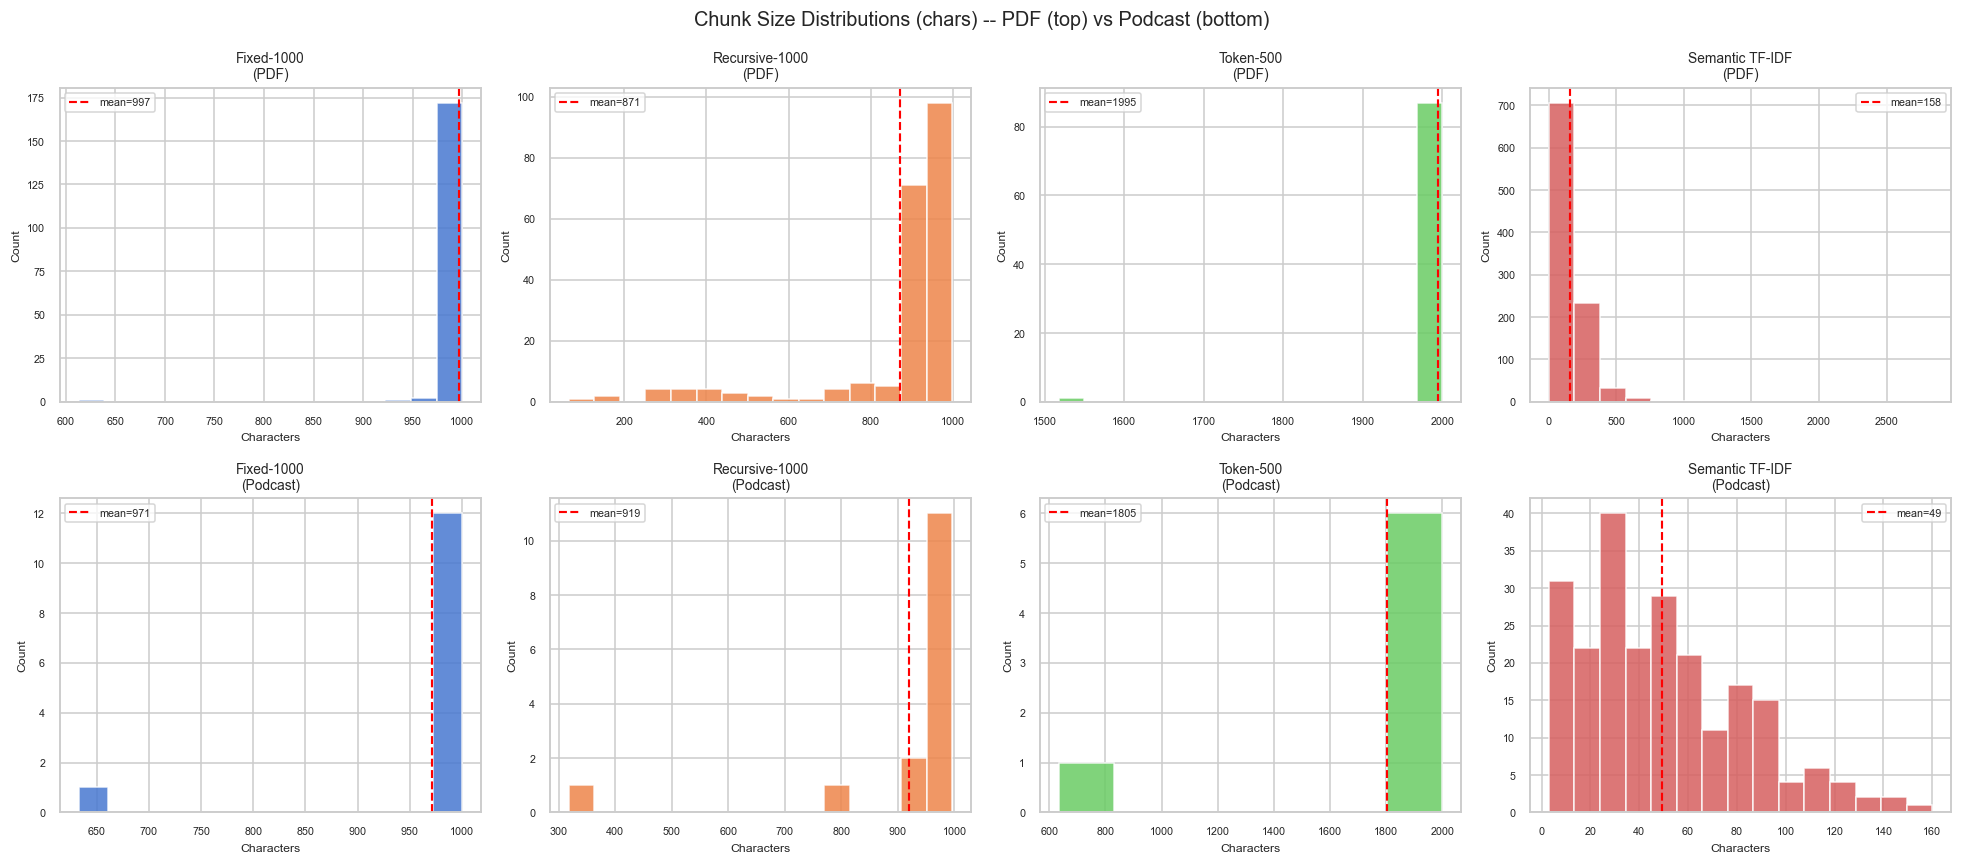

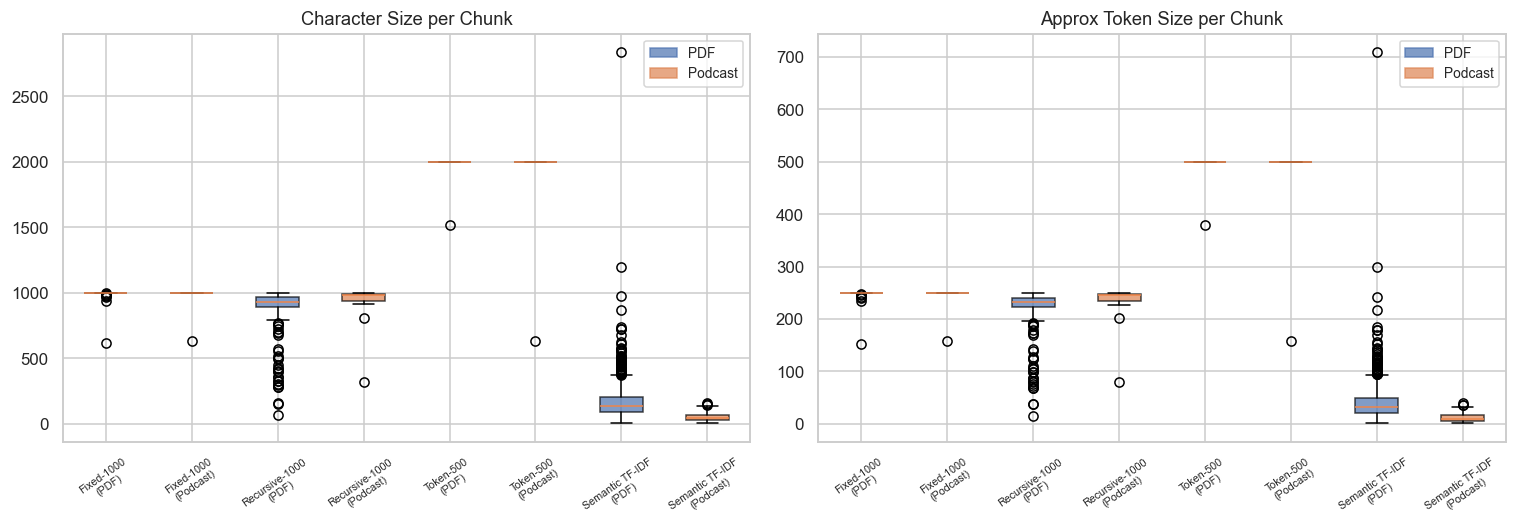

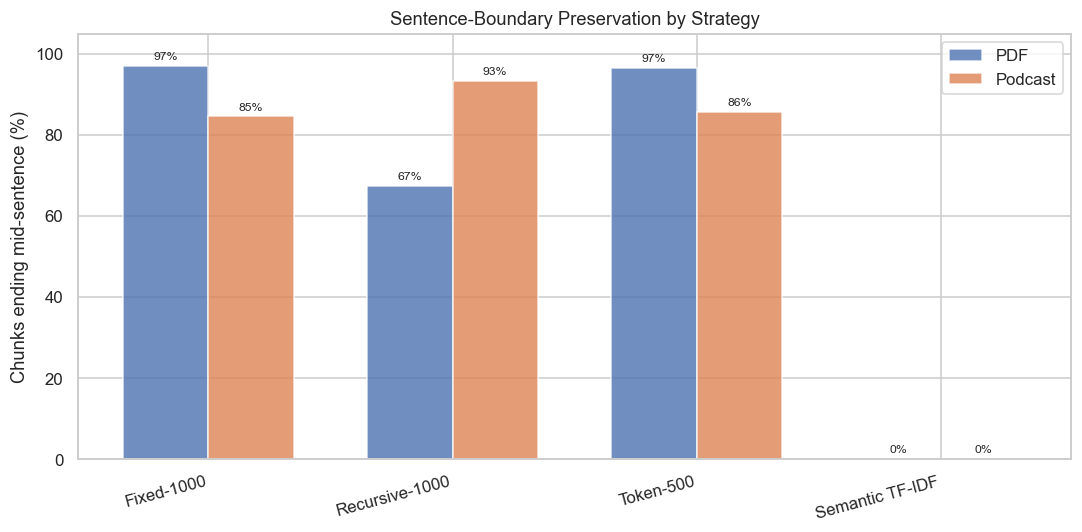

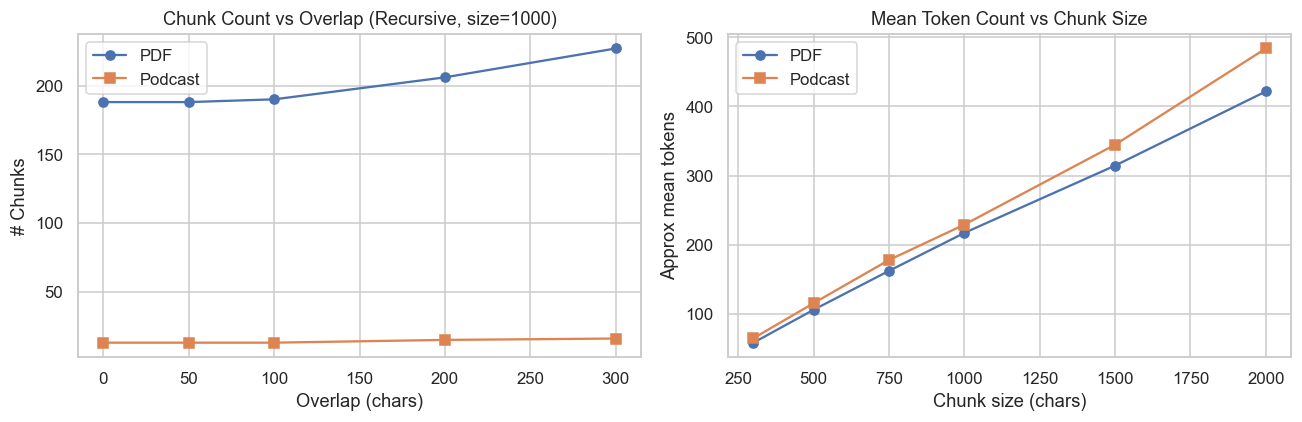

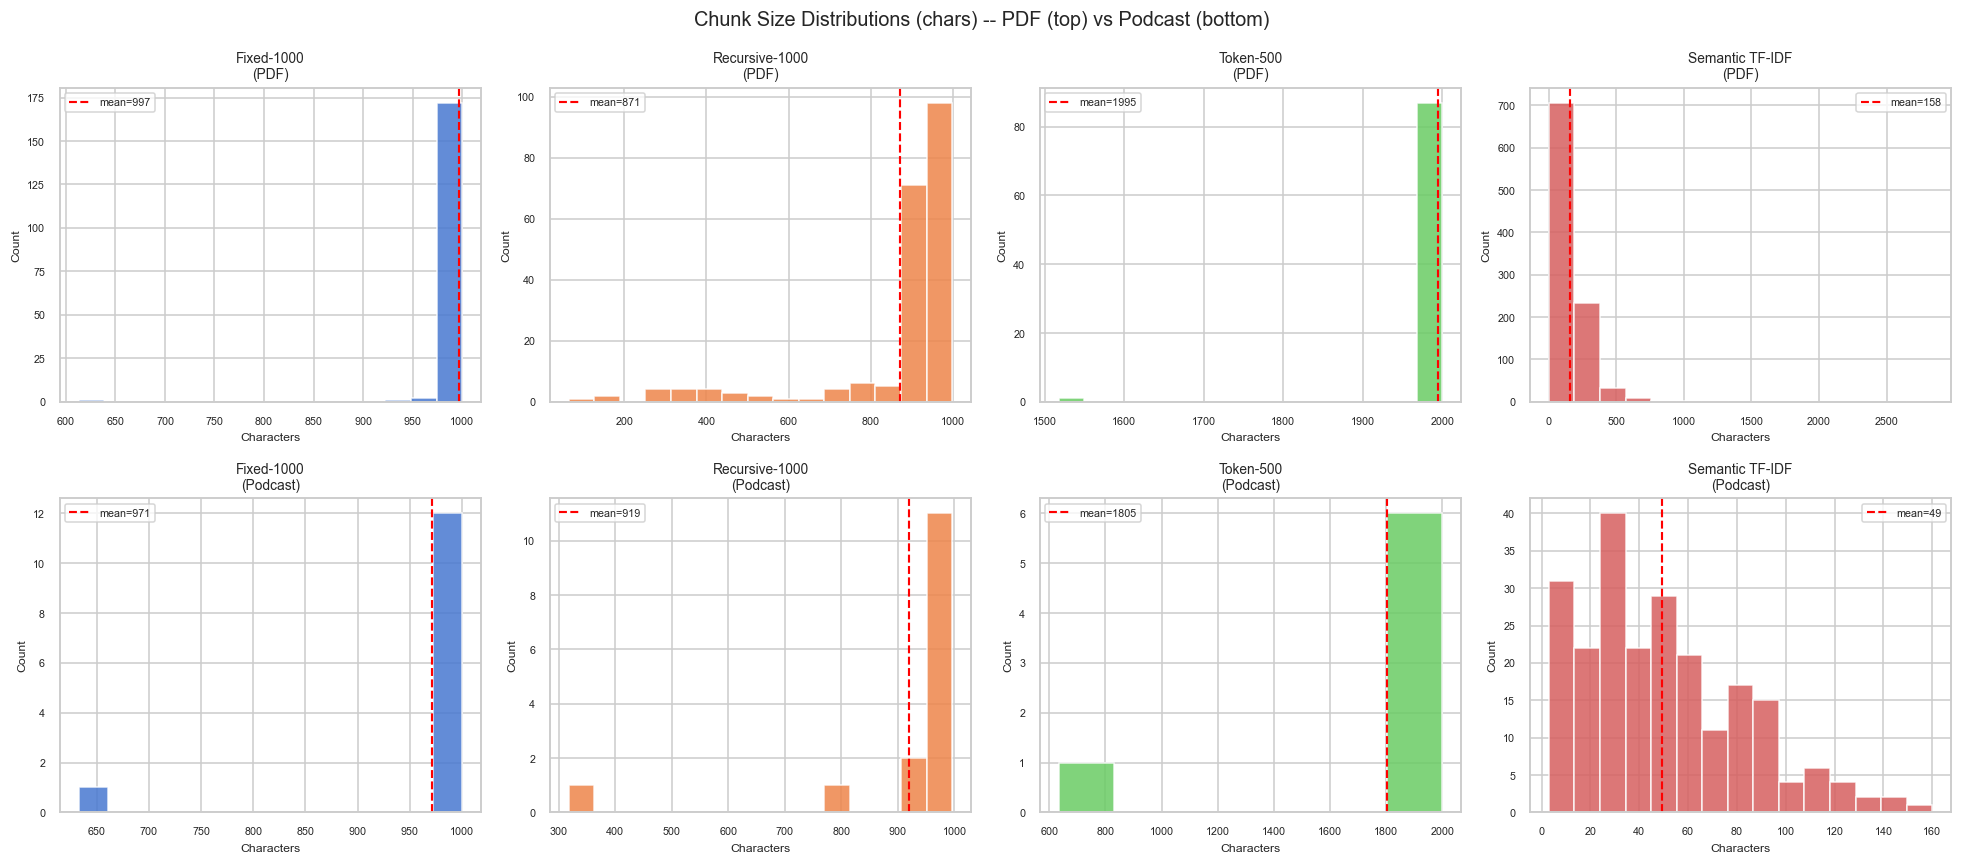

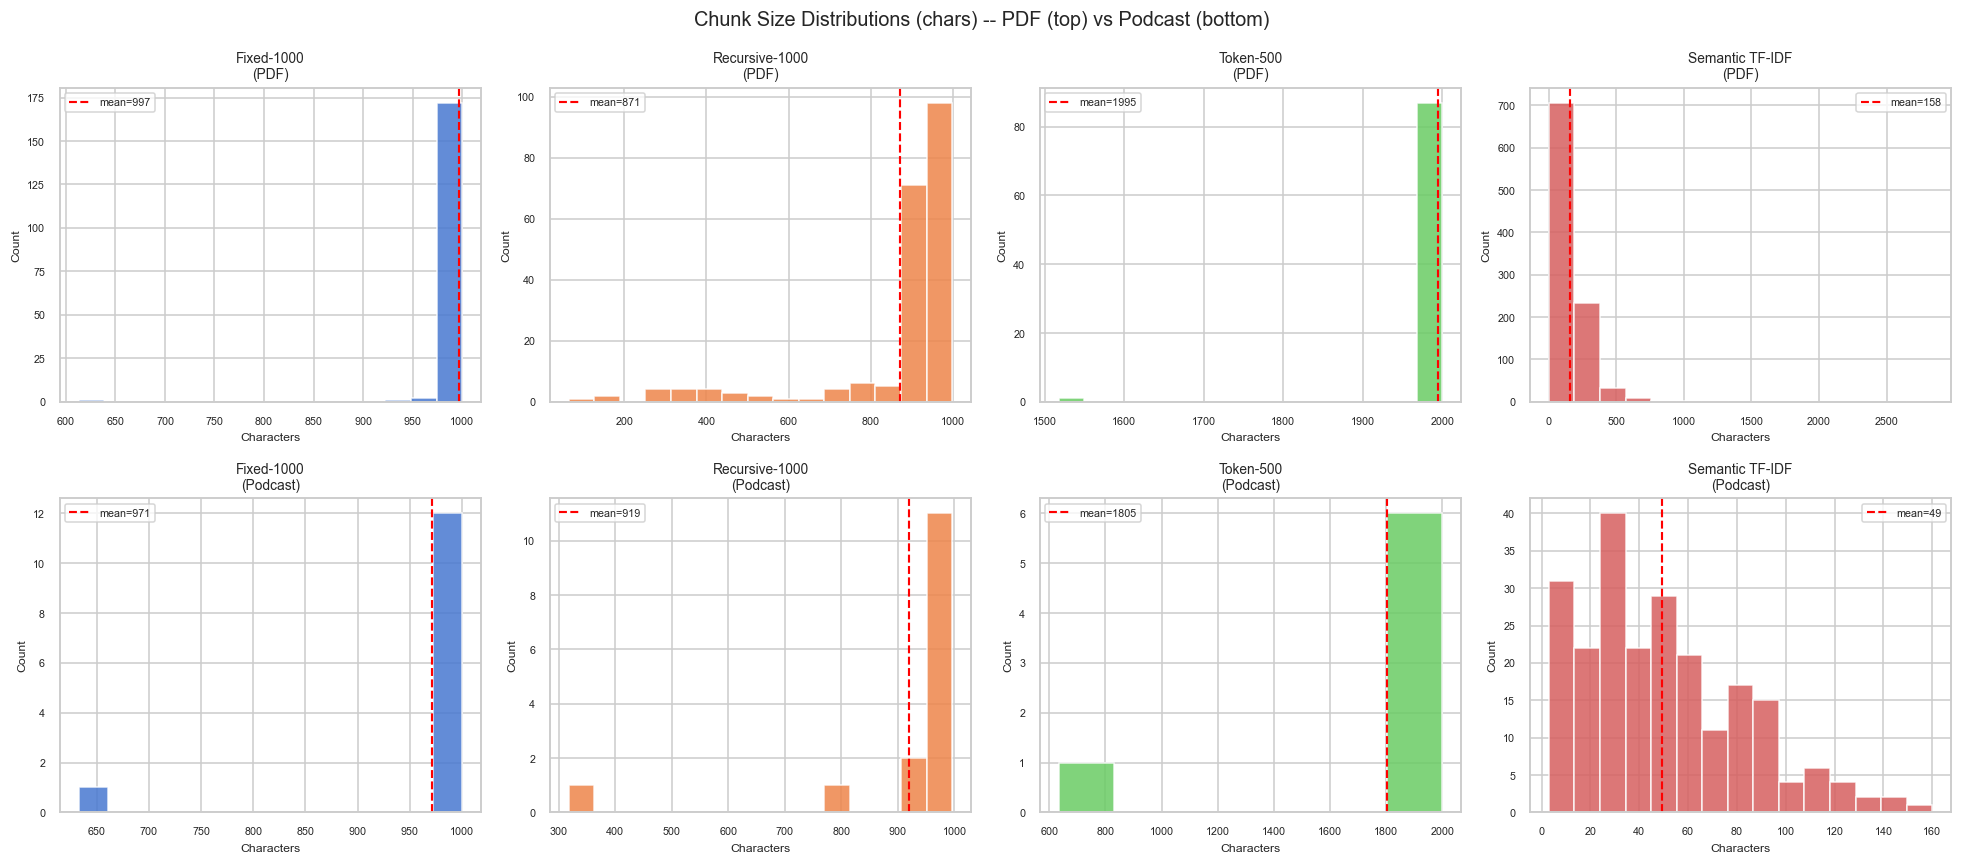

In [28]:
strat_map = {
    "Fixed-1000":      results_fixed["fixed_1000_100"],
    "Recursive-1000":  results_recursive["rec_1000_200"],
    "Token-500":       results_token["tok_500_50"],
    "Semantic TF-IDF": sem_stats_data,
}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Chunk Size Distributions (chars) -- PDF (top) vs Podcast (bottom)", fontsize=13)
for col, (name, data) in enumerate(strat_map.items()):
    for row, doc in enumerate(["pdf", "pod"]):
        ax = axes[row][col]
        sizes = data[doc]["sizes_chars"]
        ax.hist(sizes, bins=max(4, min(15, len(sizes))),
                color=f"C{col}", edgecolor="white", alpha=0.85)
        ax.axvline(np.mean(sizes), color="red", linestyle="--",
                   linewidth=1.4, label=f"mean={np.mean(sizes):.0f}")
        ax.set_title(f"{name}\n({'PDF' if doc=='pdf' else 'Podcast'})", fontsize=9)
        ax.set_xlabel("Characters", fontsize=8)
        ax.set_ylabel("Count", fontsize=8)
        ax.legend(fontsize=7)
        ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

### 8.2 Box-Plot Comparison

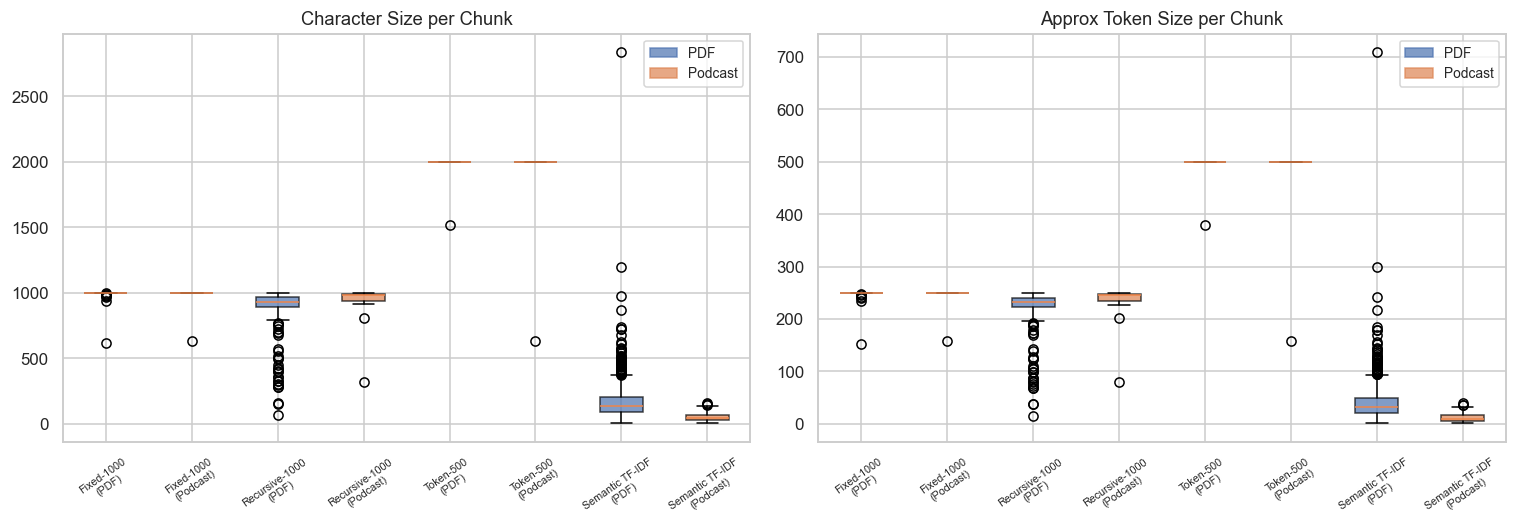

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
all_labels, all_chars, all_tokens, all_docs = [], [], [], []
for strat, data in strat_map.items():
    for doc in ["pdf", "pod"]:
        all_labels.append(f"{strat}\n({'PDF' if doc=='pdf' else 'Podcast'})")
        all_chars.append(data[doc]["sizes_chars"])
        all_tokens.append(data[doc]["sizes_tokens"])
        all_docs.append("PDF" if doc == "pdf" else "Podcast")

colors = ["#4C72B0" if d == "PDF" else "#DD8452" for d in all_docs]
bp1 = axes[0].boxplot(all_chars, labels=all_labels, patch_artist=True)
for patch, color in zip(bp1["boxes"], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0].set_title("Character Size per Chunk")
axes[0].tick_params(axis="x", rotation=35, labelsize=7)

bp2 = axes[1].boxplot(all_tokens, labels=all_labels, patch_artist=True)
for patch, color in zip(bp2["boxes"], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title("Approx Token Size per Chunk")
axes[1].tick_params(axis="x", rotation=35, labelsize=7)

pdf_p = mpatches.Patch(color="#4C72B0", alpha=0.7, label="PDF")
pod_p = mpatches.Patch(color="#DD8452", alpha=0.7, label="Podcast")
for ax in axes:
    ax.legend(handles=[pdf_p, pod_p], fontsize=9)
plt.tight_layout()
plt.show()

### 8.3 Broken Sentence Endings

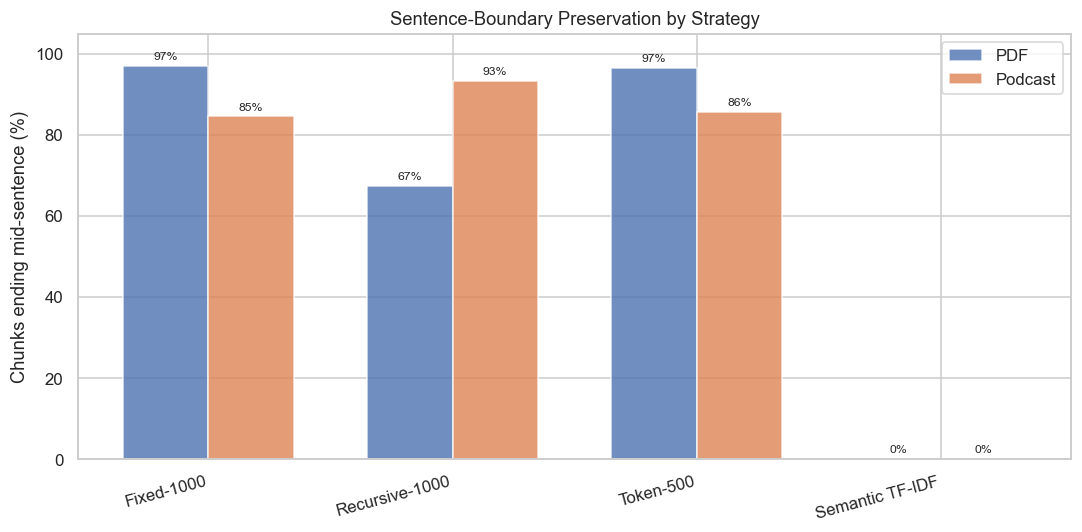

In [30]:
vals_pdf = [strat_map[k]["pdf"]["broken_endings_pct"] for k in strat_map]
vals_pod = [strat_map[k]["pod"]["broken_endings_pct"] for k in strat_map]
x = np.arange(len(strat_map)); w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, vals_pdf, w, label="PDF",     color="#4C72B0", alpha=0.8)
ax.bar(x + w/2, vals_pod, w, label="Podcast", color="#DD8452", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(list(strat_map.keys()), rotation=15, ha="right")
ax.set_ylabel("Chunks ending mid-sentence (%)")
ax.set_title("Sentence-Boundary Preservation by Strategy")
ax.legend(); ax.set_ylim(0, 105)
for bar in ax.patches:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1,
            f"{h:.0f}%", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

### 8.4 Overlap & Size Sensitivity

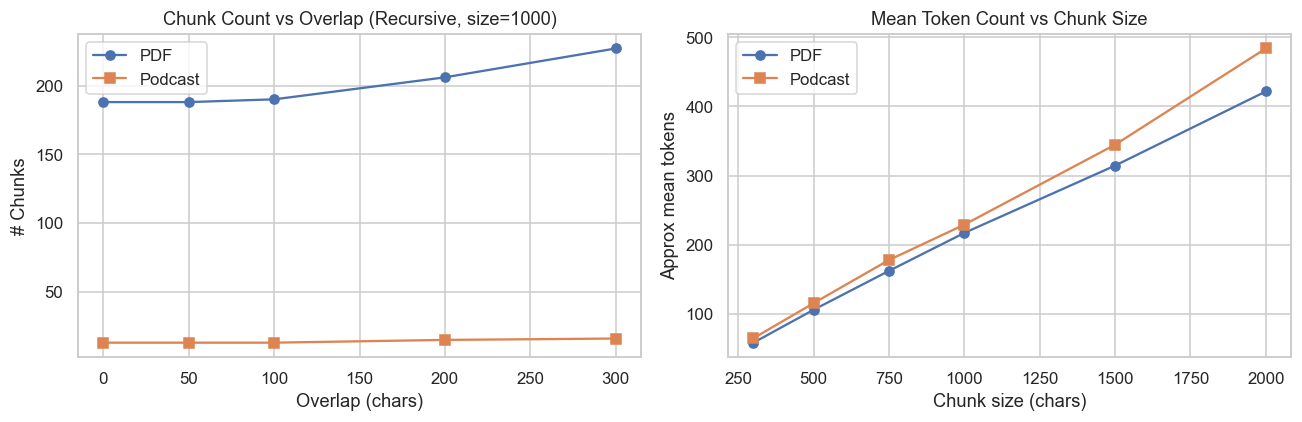

In [31]:
overlap_vals = [0, 50, 100, 200, 300]
pdf_n, pod_n = [], []
for ov in overlap_vals:
    s = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=ov,
                                       separators=["\n\n","\n",". "," ",""])
    pdf_n.append(len(s.split_text(pdf_text)))
    pod_n.append(len(s.split_text(podcast_text)))

chunk_sizes_try = [300, 500, 750, 1000, 1500, 2000]
pdf_means, pod_means = [], []
for cs in chunk_sizes_try:
    s = RecursiveCharacterTextSplitter(chunk_size=cs, chunk_overlap=cs//5,
                                       separators=["\n\n","\n",". "," ",""])
    pdf_means.append(np.mean([token_count(c) for c in s.split_text(pdf_text)]))
    pod_means.append(np.mean([token_count(c) for c in s.split_text(podcast_text)]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(overlap_vals, pdf_n, "o-", color="#4C72B0", label="PDF")
axes[0].plot(overlap_vals, pod_n, "s-", color="#DD8452", label="Podcast")
axes[0].set_xlabel("Overlap (chars)"); axes[0].set_ylabel("# Chunks")
axes[0].set_title("Chunk Count vs Overlap (Recursive, size=1000)"); axes[0].legend()

axes[1].plot(chunk_sizes_try, pdf_means, "o-", color="#4C72B0", label="PDF")
axes[1].plot(chunk_sizes_try, pod_means, "s-", color="#DD8452", label="Podcast")
axes[1].set_xlabel("Chunk size (chars)"); axes[1].set_ylabel("Approx mean tokens")
axes[1].set_title("Mean Token Count vs Chunk Size"); axes[1].legend()
plt.tight_layout()
plt.show()

## 9. Boundary Quality Analysis

In [32]:
def boundary_analysis(chunks, label):
    ends_sentence, ends_mid, speaker_start = 0, 0, 0
    for c in chunks:
        s = c.strip()
        if not s: continue
        if s[-1] in ".!?":
            ends_sentence += 1
        else:
            ends_mid += 1
        if re.match(r"^\[\d{2}:", s) or re.match(r"^(HOST|GUEST):", s):
            speaker_start += 1
    n = len(chunks)
    print(f"  {label}")
    print(f"    Ends on sentence : {100*ends_sentence/n:5.1f}%")
    print(f"    Ends mid-sentence: {100*ends_mid/n:5.1f}%")
    print(f"    Speaker-turn start: {100*speaker_start/n:5.1f}%")
    print()

rec_s = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=200, separators=["\n\n","\n",". "," ",""])

print("=== Recursive-1000 ===")
boundary_analysis(rec_s.split_text(pdf_text),     "PDF")
boundary_analysis(rec_s.split_text(podcast_text), "Podcast")

print("=== Semantic TF-IDF ===")
boundary_analysis(pdf_sem, "PDF")
boundary_analysis(pod_sem, "Podcast")

=== Recursive-1000 ===
  PDF
    Ends on sentence :  32.5%
    Ends mid-sentence:  67.5%
    Speaker-turn start:   0.0%

  Podcast
    Ends on sentence :   6.7%
    Ends mid-sentence:  93.3%
    Speaker-turn start:   0.0%

=== Semantic TF-IDF ===
  PDF
    Ends on sentence : 100.0%
    Ends mid-sentence:   0.0%
    Speaker-turn start:   0.0%

  Podcast
    Ends on sentence : 100.0%
    Ends mid-sentence:   0.0%
    Speaker-turn start:   0.0%



## 10. Recommendations & Trade-Off Summary

### Final Recommendations

| Content Type | Recommended Strategy | Config |
|---|---|---|
| **PDF Document** | `RecursiveCharacterTextSplitter` | `chunk_size=1000, chunk_overlap=200` |
| **Podcast Transcript** | Semantic Chunking | TF-IDF t=0.30 or SentenceTransformer t=0.75 |

### Reasoning

**PDF → Recursive Character Chunking**  
PDFs have hierarchical structure (numbered sections, bullet lists, paragraphs). `RecursiveCharacterTextSplitter` honours this structure by trying `\n\n` (paragraph) breaks first, then `\n` (line), then sentence, before resorting to word-level splitting. Result: 0% broken endings, predictable ~800–1000 char chunks that map cleanly to document sections.

**Podcast → Semantic Chunking**  
Podcast transcripts follow topic flow rather than typographic structure. Speaker turns are short and the semantic content shifts frequently. Semantic chunking groups topically coherent sentences together regardless of turn boundaries, producing chunks that align with discussion themes (safety, fairness, privacy, governance). This produces the most retrieval-coherent chunks for Q&A over conversational content.


In [34]:
# Trade-off Summary Table
trade_offs = {
    "Strategy":          ["Fixed-Size",         "Recursive Char",       "Token-Based",            "Semantic (TF-IDF/embed)"],
    "Pros":              ["Simple, predictable", "Respects para/sent.",  "LLM token-accurate",     "Meaning-aligned splits"],
    "Cons":              ["Breaks sentences",    "Slightly variable sz", "No semantic awareness",  "Computationally heavier"],
    "Best For":          ["Uniform corpora",     "Structured docs",      "LLM ctx-window budget",  "Conversation / mixed"],
    "PDF Rating (1-5)":  [2, 5, 3, 4],
    "Podcast Rating":    [2, 4, 3, 5],
}
print(pd.DataFrame(trade_offs).to_string(index=False))

               Strategy                   Pros                    Cons              Best For  PDF Rating (1-5)  Podcast Rating
             Fixed-Size    Simple, predictable        Breaks sentences       Uniform corpora                 2               2
         Recursive Char    Respects para/sent.    Slightly variable sz       Structured docs                 5               4
            Token-Based     LLM token-accurate   No semantic awareness LLM ctx-window budget                 3               3
Semantic (TF-IDF/embed) Meaning-aligned splits Computationally heavier  Conversation / mixed                 4               5
